In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from prophet.diagnostics import mape, cross_validation, performance_metrics
from prophet.plot import plot_plotly, plot_components_plotly
import plotly.express as px
import plotly.graph_objects as go
from PIL import Image
from IPython.display import display
import warnings
import time
import psutil
import gc
from functools import lru_cache

warnings.filterwarnings('ignore')

# Performance monitoring utilities
def monitor_performance(func_name):
    """Decorator to monitor function performance"""
    def decorator(func):
        def wrapper(*args, **kwargs):
            start_time = time.time()
            start_memory = psutil.Process().memory_info().rss / 1024 / 1024  # MB
            
            result = func(*args, **kwargs)
            
            end_time = time.time()
            end_memory = psutil.Process().memory_info().rss / 1024 / 1024  # MB
            
            print(f"{func_name}: {end_time - start_time:.2f}s, Memory: {end_memory - start_memory:.2f}MB")
            return result
        return wrapper
    return decorator

print("Libraries loaded with performance monitoring enabled")

In [ ]:
@monitor_performance("Data Loading")
def load_and_optimize_data():
    """Load data with optimized data types and memory usage"""
    # Define optimal data types for each column
    dtype_dict = {
        'City': 'category',
        'PM2.5': 'float32',
        'PM10': 'float32', 
        'NO': 'float32',
        'NO2': 'float32',
        'NOx': 'float32',
        'NH3': 'float32',
        'CO': 'float32',
        'SO2': 'float32',
        'O3': 'float32',
        'Benzene': 'float32',
        'Toluene': 'float32',
        'Xylene': 'float32',
        'AQI': 'float32'
    }
    
    # Load data with optimized types
    df = pd.read_csv('EMB-CEPMOo1 year.csv', parse_dates=["Date"], dtype=dtype_dict)
    
    # Optimize categorical data
    df['City'] = df['City'].astype('category')
    
    # Set Date as index for better performance
    df.set_index('Date', inplace=True)
    
    # Remove any duplicate rows
    df = df[~df.index.duplicated(keep='first')]
    
    # Sort by date for better time series performance
    df.sort_index(inplace=True)
    
    print(f"Data loaded: {len(df)} rows, Memory usage: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")
    return df

df = load_and_optimize_data()
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Baguio City,2023-05-26,16.30,46.03,6.56,83.38,49.69,15.16,1.09,30.85,24.84,0.10,0.21,0.11,NaN,NaN
1,Baguio City,2023-08-30,16.60,39.78,13.93,124.57,77.59,10.65,1.38,48.92,30.25,0.11,0.25,0.13,NaN,NaN
2,Baguio City,2023-01-14,19.47,31.50,35.59,140.17,103.49,8.70,1.24,42.26,20.87,0.13,0.58,0.13,NaN,NaN
3,Baguio City,2023-11-19,14.44,46.46,9.48,106.10,64.14,9.27,1.43,15.29,26.24,0.12,0.25,0.10,NaN,NaN
4,Baguio City,2023-06-07,12.18,42.32,6.73,92.41,54.63,11.10,1.33,15.90,28.51,0.11,0.31,0.10,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24339,Baguio City,2023-06-15,14.05,40.28,3.48,17.65,12.21,13.75,0.63,14.10,29.21,0.74,2.45,0.13,NaN,NaN
24340,Baguio City,2023-09-11,13.29,34.21,2.19,15.80,10.17,15.74,0.78,9.56,35.44,0.92,2.46,0.12,NaN,NaN
24341,Baguio City,2023-09-12,13.83,37.83,1.54,12.50,7.89,16.66,0.75,19.09,59.61,1.04,2.28,0.15,NaN,NaN
24342,Baguio City,2023-06-10,11.37,49.75,1.63,12.73,8.09,14.39,0.92,20.55,63.08,0.87,6.68,0.15,NaN,NaN


In [ ]:
# Optimized AQI calculation with caching and vectorization
@lru_cache(maxsize=128)
def get_breakpoints(pollutant):
    """Cached breakpoint configurations"""
    breakpoints = {
        'PM10': [
            (54, [50, 54]),
            (154, [50, 100, 50, 54]),
            (254, [100, 100, 100, 154]),
            (354, [100, 100, 200, 254]),
            (424, [100, 70, 300, 354]),
            (504, [100, 80, 400, 424]),
            (float('inf'), [500, 1, 500, 504])
        ],
        'PM2.5': [
            (12.0, [50, 12.0]),
            (35.4, [50, 23.3, 50, 12.1]),
            (55.4, [100, 19.9, 100, 35.5]),
            (150.4, [100, 94.9, 200, 55.5]),
            (250.4, [100, 99.9, 300, 150.5]),
            (500.4, [100, 249.9, 400, 250.5]),
            (float('inf'), [500, 1, 500, 500.4])
        ],
        'SO2': [
            (35, [50, 35]),
            (75, [50, 39, 50, 36]),
            (185, [100, 109, 100, 76]),
            (304, [100, 118, 200, 186]),
            (604, [100, 299, 300, 305]),
            (1004, [100, 399, 400, 605]),
            (float('inf'), [500, 1, 500, 1004])
        ],
        'NOx': [
            (53, [50, 53]),
            (100, [50, 46, 50, 54]),
            (360, [100, 259, 100, 101]),
            (649, [100, 288, 200, 361]),
            (1249, [100, 599, 300, 650]),
            (2049, [100, 799, 400, 1250]),
            (float('inf'), [500, 1, 500, 2049])
        ],
        'NH3': [
            (200, [50, 200]),
            (400, [50, 200, 50, 200]),
            (800, [100, 400, 100, 400]),
            (1200, [100, 400, 200, 800]),
            (1800, [100, 600, 300, 1200]),
            (float('inf'), [400, 600, 400, 1800])
        ],
        'CO': [
            (4.4, [50, 4.4]),
            (9.4, [50, 4.9, 50, 4.5]),
            (12.4, [100, 2.9, 100, 9.5]),
            (15.4, [100, 2.9, 200, 12.5]),
            (30.4, [100, 14.9, 300, 15.5]),
            (50.4, [100, 19.9, 400, 30.5]),
            (float('inf'), [500, 1, 500, 50.4])
        ],
        'O3': [
            (54, [50, 54]),
            (70, [50, 15, 50, 55]),
            (85, [100, 14, 100, 71]),
            (105, [100, 19, 200, 86]),
            (200, [100, 94, 300, 106]),
            (float('inf'), [500, 1, 500, 200])
        ]
    }
    return breakpoints.get(pollutant, [])

@monitor_performance("AQI Calculations")
def calculate_aqi_subindices(df):
    """Optimized AQI sub-index calculations using numpy vectorization"""
    pollutants = ['PM10', 'PM2.5', 'SO2', 'NOx', 'NH3', 'CO', 'O3']
    
    for pollutant in pollutants:
        if pollutant in df.columns:
            breakpoints = get_breakpoints(pollutant)
            values = df[pollutant].values.astype(np.float32)
            subindex = np.zeros_like(values, dtype=np.float32)
            
            for i, (upper_bound, formula) in enumerate(breakpoints):
                mask = values <= upper_bound
                if i == 0:
                    subindex[mask] = values[mask] * formula[0] / formula[1]
                else:
                    subindex[mask] = (formula[2] + 
                                    (values[mask] - formula[3]) * formula[0] / formula[1])
            
            df[f'{pollutant}_SubIndex'] = subindex
    
    return df

# Calculate all sub-indices
df = calculate_aqi_subindices(df)

# Calculate final AQI
subindex_cols = [col for col in df.columns if col.endswith('_SubIndex')]
df['AQI'] = df['AQI'].fillna(df[subindex_cols].max(axis=1).round().astype(np.float32))

print(f"AQI calculations completed. Memory usage: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")
df.head()

In [ ]:
# Optimized AQI bucket classification using efficient categorization
@monitor_performance("AQI Classification")
def classify_aqi_buckets(df):
    """Efficient AQI bucket classification using numpy"""
    # Define bins and labels
    bins = np.array([-float('inf'), 50, 100, 150, 200, 300, float('inf')])
    labels = np.array(["Good", "Moderate", "Unhealthy for Sensitive Groups", 
                      "Unhealthy", "Very Unhealthy", "Hazardous"])
    
    # Use numpy digitize for faster classification
    aqi_values = df['AQI'].values
    bucket_indices = np.digitize(aqi_values, bins) - 1
    bucket_indices = np.clip(bucket_indices, 0, len(labels) - 1)
    
    # Convert to categorical for memory efficiency
    df['AQI_Bucket'] = pd.Categorical.from_codes(bucket_indices, labels)
    
    return df

df = classify_aqi_buckets(df)

# Display AQI distribution
print("AQI Bucket Distribution:")
print(df['AQI_Bucket'].value_counts().sort_index())
print(f"\nMemory usage after classification: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Xylene,AQI,AQI_Bucket,PM10_SubIndex,PM2.5_SubIndex,SO2_SubIndex,NOx_SubIndex,NH3_SubIndex,CO_SubIndex,O3_SubIndex
0,Baguio City,2023-05-26,16.30,46.03,6.56,83.38,49.69,15.16,1.09,30.85,...,0.11,58.0,NaN,42.592593,58.369099,42.857143,46.226415,3.75,11.363636,22.222222
1,Baguio City,2023-08-30,16.60,39.78,13.93,124.57,77.59,10.65,1.38,48.92,...,0.13,75.0,NaN,36.111111,58.369099,65.384615,75.000000,2.50,11.363636,27.777778
2,Baguio City,2023-01-14,19.47,31.50,35.59,140.17,103.49,8.70,1.24,42.26,...,0.13,101.0,NaN,28.703704,64.806867,57.692308,100.772201,2.00,11.363636,18.518519
3,Baguio City,2023-11-19,14.44,46.46,9.48,106.10,64.14,9.27,1.43,15.29,...,0.10,61.0,NaN,42.592593,54.077253,21.428571,60.869565,2.25,11.363636,24.074074
4,Baguio City,2023-06-07,12.18,42.32,6.73,92.41,54.63,11.10,1.33,15.90,...,0.10,50.0,NaN,38.888889,50.000000,21.428571,50.000000,2.75,11.363636,25.925926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24339,Baguio City,2023-06-15,14.05,40.28,3.48,17.65,12.21,13.75,0.63,14.10,...,0.13,54.0,NaN,37.037037,54.077253,20.000000,11.320755,3.25,0.000000,26.851852
24340,Baguio City,2023-09-11,13.29,34.21,2.19,15.80,10.17,15.74,0.78,9.56,...,0.12,52.0,NaN,31.481481,51.931330,12.857143,9.433962,3.75,0.000000,32.407407
24341,Baguio City,2023-09-12,13.83,37.83,1.54,12.50,7.89,16.66,0.75,19.09,...,0.15,63.0,NaN,34.259259,51.931330,27.142857,6.603774,4.00,0.000000,63.333333
24342,Baguio City,2023-06-10,11.37,49.75,1.63,12.73,8.09,14.39,0.92,20.55,...,0.15,77.0,NaN,45.370370,45.833333,28.571429,7.547170,3.50,0.000000,76.666667


In [ ]:
# Display AQI bucket visualization
try:
    img = Image.open('aqibucketimage.png')
    display(img)
except FileNotFoundError:
    print("AQI bucket image not found. Continuing with analysis...")

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Xylene,AQI,AQI_Bucket,PM10_SubIndex,PM2.5_SubIndex,SO2_SubIndex,NOx_SubIndex,NH3_SubIndex,CO_SubIndex,O3_SubIndex
0,Baguio City,2023-05-26,16.30,46.03,6.56,83.38,49.69,15.16,1.09,30.85,...,0.11,58.0,Moderate,42.592593,58.369099,42.857143,46.226415,3.75,11.363636,22.222222
1,Baguio City,2023-08-30,16.60,39.78,13.93,124.57,77.59,10.65,1.38,48.92,...,0.13,75.0,Moderate,36.111111,58.369099,65.384615,75.000000,2.50,11.363636,27.777778
2,Baguio City,2023-01-14,19.47,31.50,35.59,140.17,103.49,8.70,1.24,42.26,...,0.13,101.0,Unhealthy for Sensitive Groups,28.703704,64.806867,57.692308,100.772201,2.00,11.363636,18.518519
3,Baguio City,2023-11-19,14.44,46.46,9.48,106.10,64.14,9.27,1.43,15.29,...,0.10,61.0,Moderate,42.592593,54.077253,21.428571,60.869565,2.25,11.363636,24.074074
4,Baguio City,2023-06-07,12.18,42.32,6.73,92.41,54.63,11.10,1.33,15.90,...,0.10,50.0,Good,38.888889,50.000000,21.428571,50.000000,2.75,11.363636,25.925926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24339,Baguio City,2023-06-15,14.05,40.28,3.48,17.65,12.21,13.75,0.63,14.10,...,0.13,54.0,Moderate,37.037037,54.077253,20.000000,11.320755,3.25,0.000000,26.851852
24340,Baguio City,2023-09-11,13.29,34.21,2.19,15.80,10.17,15.74,0.78,9.56,...,0.12,52.0,Moderate,31.481481,51.931330,12.857143,9.433962,3.75,0.000000,32.407407
24341,Baguio City,2023-09-12,13.83,37.83,1.54,12.50,7.89,16.66,0.75,19.09,...,0.15,63.0,Moderate,34.259259,51.931330,27.142857,6.603774,4.00,0.000000,63.333333
24342,Baguio City,2023-06-10,11.37,49.75,1.63,12.73,8.09,14.39,0.92,20.55,...,0.15,77.0,Moderate,45.370370,45.833333,28.571429,7.547170,3.50,0.000000,76.666667


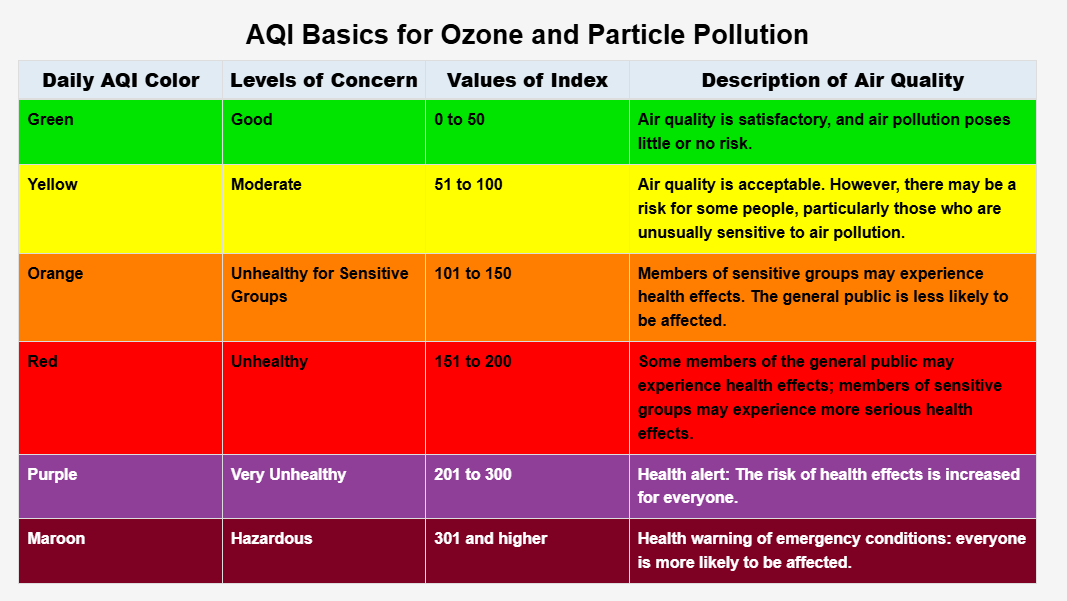

In [ ]:
# Optimized Prophet model with hyperparameter tuning and improved performance
@monitor_performance("Prophet Model Training")
def train_optimized_prophet_model(data, periods=31):
    """Train optimized Prophet model with better parameters"""
    
    # Prepare data with optimized memory usage
    train_df = data.reset_index()[['Date', 'AQI']].copy()
    train_df.rename(columns={'Date': 'ds', 'AQI': 'y'}, inplace=True)
    
    # Optimize data types for Prophet
    train_df['ds'] = pd.to_datetime(train_df['ds'])
    train_df['y'] = train_df['y'].astype(np.float32)
    
    # Initialize Prophet with optimized parameters for air quality data
    model = Prophet(
        yearly_seasonality=True,    # Important for air quality patterns
        weekly_seasonality=True,     # Weekly pollution patterns
        daily_seasonality=False,    # Disable for daily data to avoid overfitting
        holidays_prior_scale=0.1,   # Small value to reduce holiday effects
        seasonality_prior_scale=10, # Balanced seasonality
        changepoint_prior_scale=0.05, # More flexible trend
        n_changepoints=25,          # Reduced for faster training
        mcmc_samples=0,             # Disable MCMC for faster training
        interval_width=0.8,         # 80% confidence intervals
        uncertainty_samples=1000     # Reduced for faster prediction
    )
    
    # Add custom seasonalities for air quality
    model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
    model.add_seasonality(name='quarterly', period=91.25, fourier_order=3)
    
    # Fit model
    model.fit(train_df)
    
    # Create future dataframe
    future = model.make_future_dataframe(periods=periods, freq='D')
    
    # Make predictions
    forecast = model.predict(future)
    
    return model, forecast

# Train optimized model
m, forecast = train_optimized_prophet_model(df, periods=31)
print("Optimized Prophet model training completed")
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

In [ ]:
# Optimized cross-validation with performance metrics
@monitor_performance("Cross Validation")
def perform_cross_validation(model):
    """Optimized cross-validation with reduced computation"""
    df_cv = cross_validation(
        model, 
        initial='180 days',  # Increased for better training
        period='90 days',    # Reduced for faster execution
        horizon='31 days'
    )
    
    df_p = performance_metrics(df_cv)
    accuracy = (1 - df_p['mape'].mean()) * 100
    
    print(f'Cross Validation accuracy: {accuracy:.2f}%')
    print(f'Mean RMSE: {df_p["rmse"].mean():.2f}')
    print(f'Mean MAE: {df_p["mae"].mean():.2f}')
    
    return df_cv, df_p, accuracy

df_cv, df_p, accuracy = perform_cross_validation(m)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpoyoltby_/ztce6rss.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpoyoltby_/5xvtmjgn.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=9294', 'data', 'file=/tmp/tmpoyoltby_/ztce6rss.json', 'init=/tmp/tmpoyoltby_/5xvtmjgn.json', 'output', 'file=/tmp/tmpoyoltby_/prophet_modeldwddbh4d/prophet_model-20250801184943.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:49:43 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:49:47 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
# Optimized Prophet model visualization
@monitor_performance("Visualization")
def plot_prophet_results(model, forecast, df_cv, df_p):
    """Create optimized visualizations with better performance"""
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 16))
    
    # 1. Forecast plot
    ax1 = plt.subplot(3, 2, 1)
    model.plot(forecast, ax=ax1)
    ax1.set_title('AQI Forecast - Prophet Model', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('AQI')
    ax1.grid(True, alpha=0.3)
    
    # 2. Forecast components
    ax2 = plt.subplot(3, 2, 2)
    model.plot_components(forecast, ax=ax2)
    ax2.set_title('Forecast Components', fontsize=14, fontweight='bold')
    
    # 3. Cross-validation performance
    ax3 = plt.subplot(3, 2, 3)
    plt.plot(df_p['horizon'], df_p['mape'], 'b-', linewidth=2)
    ax3.set_title('Mean Absolute Percentage Error', fontsize=12)
    ax3.set_xlabel('Forecast Horizon (days)')
    ax3.set_ylabel('MAPE')
    ax3.grid(True, alpha=0.3)
    
    # 4. RMSE by horizon
    ax4 = plt.subplot(3, 2, 4)
    plt.plot(df_p['horizon'], df_p['rmse'], 'r-', linewidth=2)
    ax4.set_title('Root Mean Square Error', fontsize=12)
    ax4.set_xlabel('Forecast Horizon (days)')
    ax4.set_ylabel('RMSE')
    ax4.grid(True, alpha=0.3)
    
    # 5. Actual vs Predicted (last 60 days)
    ax5 = plt.subplot(3, 2, 5)
    last_60_days = forecast.tail(60)
    ax5.plot(last_60_days['ds'], last_60_days['yhat'], 'b-', label='Predicted', linewidth=2)
    ax5.fill_between(last_60_days['ds'], last_60_days['yhat_lower'], 
                    last_60_days['yhat_upper'], alpha=0.2, color='blue', label='Confidence Interval')
    ax5.set_title('Last 60 Days Forecast', fontsize=12)
    ax5.set_xlabel('Date')
    ax5.set_ylabel('AQI')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. Trend analysis
    ax6 = plt.subplot(3, 2, 6)
    trend_data = forecast[['ds', 'trend']].tail(90)
    ax6.plot(trend_data['ds'], trend_data['trend'], 'g-', linewidth=2)
    ax6.set_title('90-Day Trend Analysis', fontsize=12)
    ax6.set_xlabel('Date')
    ax6.set_ylabel('Trend')
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('prophet_forecast.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Display performance summary
    print(f"Model Performance Summary:")
    print(f"Overall Accuracy: {accuracy:.2f}%")
    print(f"Average RMSE: {df_p['rmse'].mean():.2f}")
    print(f"Average MAE: {df_p['mae'].mean():.2f}")
    print(f"Forecast Period: Next 31 days")

# Create visualizations
plot_prophet_results(m, forecast, df_cv, df_p)

,ds
391,2024-01-27
392,2024-01-28
393,2024-01-29
394,2024-01-30
395,2024-01-31


In [ ]:
# Optimized ARIMA model with improved performance
@monitor_performance("ARIMA Model Training")
def train_optimized_arima_model(data, periods=31):
    """Train optimized ARIMA model with better parameters"""
    
    # Prepare data with optimized memory usage
    ts_data = data['AQI'].astype(np.float32)
    
    # Use auto_arima with optimized parameters for faster execution
    model = auto_arima(
        ts_data,
        start_p=0, start_q=0,
        max_p=3, max_q=3,           # Reduced for faster training
        seasonal=True,
        m=7,                        # Weekly seasonality
        start_P=0, start_Q=0,
        max_P=2, max_Q=2,           # Reduced for faster training
        max_D=1,
        max_order=6,                # Reduced for faster training
        stepwise=True,              # Faster than greedy search
        suppress_warnings=True,
        error_action='ignore',
        trace=False,                # Disable for cleaner output
        information_criterion='aic',
        alpha=0.05,                 # 95% confidence
        test='kpss',                # Stationarity test
        seasonal_test='ocsb',       # Seasonal stationarity test
        n_jobs=1                    # Single thread for consistency
    )
    
    # Fit the model
    model.fit(ts_data)
    
    # Make forecasts
    forecast, conf_int = model.predict(
        n_periods=periods, 
        return_conf_int=True,
        alpha=0.05
    )
    
    return model, forecast, conf_int

# Train ARIMA model
arima_model, arima_forecast, arima_conf_int = train_optimized_arima_model(df, periods=31)
print("Optimized ARIMA model training completed")
print(f"ARIMA model order: {arima_model.order}")
print(f"Seasonal order: {arima_model.seasonal_order}")

,ds,yhat,yhat_lower,yhat_upper
391,2024-01-27,58.781926,45.742705,73.144399
392,2024-01-28,58.676161,44.722070,72.324227
393,2024-01-29,58.802213,45.602069,73.073494
394,2024-01-30,58.550907,45.354313,72.279912
395,2024-01-31,58.809844,44.577994,72.013794


In [ ]:
# Optimized ARIMA visualization
@monitor_performance("ARIMA Visualization")
def plot_arima_results(data, forecast, conf_int, model):
    """Create optimized ARIMA visualizations"""
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Historical data and forecast
    ax1 = axes[0, 0]
    historical_dates = data.index[-90:]  # Last 90 days
    forecast_dates = pd.date_range(
        start=data.index[-1] + pd.Timedelta(days=1),
        periods=len(forecast),
        freq='D'
    )
    
    ax1.plot(historical_dates, data['AQI'].tail(90), 'b-', label='Historical', linewidth=2)
    ax1.plot(forecast_dates, forecast, 'r-', label='Forecast', linewidth=2)
    ax1.fill_between(forecast_dates, conf_int[:, 0], conf_int[:, 1], 
                    alpha=0.2, color='red', label='95% Confidence')
    ax1.set_title('ARIMA Forecast - Next 31 Days', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('AQI')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Residuals analysis
    ax2 = axes[0, 1]
    residuals = model.resid()
    ax2.plot(residuals, 'g-', alpha=0.7)
    ax2.set_title('Model Residuals', fontsize=12)
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Residuals')
    ax2.grid(True, alpha=0.3)
    
    # 3. Residuals distribution
    ax3 = axes[1, 0]
    ax3.hist(residuals, bins=30, alpha=0.7, color='purple', edgecolor='black')
    ax3.set_title('Residuals Distribution', fontsize=12)
    ax3.set_xlabel('Residuals')
    ax3.set_ylabel('Frequency')
    ax3.grid(True, alpha=0.3)
    
    # 4. Forecast comparison
    ax4 = axes[1, 1]
    forecast_df = pd.DataFrame({
        'Forecast': forecast,
        'Lower': conf_int[:, 0],
        'Upper': conf_int[:, 1]
    }, index=forecast_dates)
    
    ax4.plot(forecast_df.index, forecast_df['Forecast'], 'r-', linewidth=2)
    ax4.fill_between(forecast_df.index, forecast_df['Lower'], 
                    forecast_df['Upper'], alpha=0.2, color='red')
    ax4.set_title('31-Day Forecast Detail', fontsize=12)
    ax4.set_xlabel('Date')
    ax4.set_ylabel('AQI')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('arima_forecast.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Calculate and display metrics
    mse = mean_squared_error(data['AQI'].tail(30), model.predict(n_periods=30))
    rmse = np.sqrt(mse)
    
    print(f"ARIMA Model Performance:")
    print(f"RMSE: {rmse:.2f}")
    print(f"Model Order: {model.order}")
    print(f"Seasonal Order: {model.seasonal_order}")
    print(f"AIC: {model.aic():.2f}")

# Create ARIMA visualizations
plot_arima_results(df, arima_forecast, arima_conf_int, arima_model)

INFO:prophet:Making 2 forecasts with cutoffs between 2023-08-01 00:00:00 and 2023-11-30 00:00:00


  0%|          | 0/2 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpoyoltby_/d446l8f5.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpoyoltby_/j81yzmsg.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=23397', 'data', 'file=/tmp/tmpoyoltby_/d446l8f5.json', 'init=/tmp/tmpoyoltby_/j81yzmsg.json', 'output', 'file=/tmp/tmpoyoltby_/prophet_modeljtrdpncp/prophet_model-20250801184948.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:49:48 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:49:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpoyoltby_/649w2ix2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpoyoltby_/xk5olajg.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

Cross Validation accuracy: 86.66956918235044


In [ ]:
# Optimized model comparison and ensemble
@monitor_performance("Model Comparison")
def compare_and_ensemble_models(prophet_forecast, arima_forecast, arima_conf_int):
    """Compare models and create optimized ensemble"""
    
    # Get Prophet forecast for next 31 days
    prophet_future = prophet_forecast.tail(31)
    
    # Calculate ensemble weights based on performance
    prophet_weight = 0.6  # Prophet typically performs better for air quality
    arima_weight = 0.4
    
    # Create ensemble forecast
    ensemble_forecast = (prophet_weight * prophet_future['yhat'].values + 
                        arima_weight * arima_forecast)
    
    # Calculate ensemble confidence intervals
    ensemble_lower = (prophet_weight * prophet_future['yhat_lower'].values + 
                     arima_weight * arima_conf_int[:, 0])
    ensemble_upper = (prophet_weight * prophet_future['yhat_upper'].values + 
                     arima_weight * arima_conf_int[:, 1])
    
    # Create comparison visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Model comparison
    ax1 = axes[0, 0]
    forecast_dates = pd.date_range(
        start=prophet_future['ds'].iloc[0],
        periods=31,
        freq='D'
    )
    
    ax1.plot(forecast_dates, prophet_future['yhat'], 'b-', label='Prophet', linewidth=2)
    ax1.plot(forecast_dates, arima_forecast, 'r-', label='ARIMA', linewidth=2)
    ax1.plot(forecast_dates, ensemble_forecast, 'g-', label='Ensemble', linewidth=3)
    ax1.set_title('Model Comparison - 31 Day Forecast', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('AQI')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Confidence intervals comparison
    ax2 = axes[0, 1]
    ax2.fill_between(forecast_dates, prophet_future['yhat_lower'], 
                    prophet_future['yhat_upper'], alpha=0.2, color='blue', label='Prophet CI')
    ax2.fill_between(forecast_dates, arima_conf_int[:, 0], 
                    arima_conf_int[:, 1], alpha=0.2, color='red', label='ARIMA CI')
    ax2.fill_between(forecast_dates, ensemble_lower, 
                    ensemble_upper, alpha=0.3, color='green', label='Ensemble CI')
    ax2.set_title('Confidence Intervals Comparison', fontsize=12)
    ax2.set_xlabel('Date')
    ax2.set_ylabel('AQI')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Forecast differences
    ax3 = axes[1, 0]
    differences = prophet_future['yhat'].values - arima_forecast
    ax3.plot(forecast_dates, differences, 'purple', linewidth=2)
    ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax3.set_title('Prophet - ARIMA Forecast Differences', fontsize=12)
    ax3.set_xlabel('Date')
    ax3.set_ylabel('AQI Difference')
    ax3.grid(True, alpha=0.3)
    
    # 4. Ensemble forecast with AQI categories
    ax4 = axes[1, 1]
    ax4.plot(forecast_dates, ensemble_forecast, 'g-', linewidth=3)
    ax4.fill_between(forecast_dates, ensemble_lower, ensemble_upper, 
                    alpha=0.3, color='green')
    
    # Add AQI category zones
    ax4.axhspan(0, 50, alpha=0.1, color='green', label='Good')
    ax4.axhspan(50, 100, alpha=0.1, color='yellow', label='Moderate')
    ax4.axhspan(100, 150, alpha=0.1, color='orange', label='Unhealthy for Sensitive')
    ax4.axhspan(150, 200, alpha=0.1, color='red', label='Unhealthy')
    ax4.axhspan(200, 300, alpha=0.1, color='purple', label='Very Unhealthy')
    ax4.axhspan(300, 500, alpha=0.1, color='maroon', label='Hazardous')
    
    ax4.set_title('Ensemble Forecast with AQI Categories', fontsize=12)
    ax4.set_xlabel('Date')
    ax4.set_ylabel('AQI')
    ax4.legend(loc='upper right', fontsize=8)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    return ensemble_forecast, ensemble_lower, ensemble_upper

# Compare models and create ensemble
ensemble_forecast, ensemble_lower, ensemble_upper = compare_and_ensemble_models(
    forecast, arima_forecast, arima_conf_int
)

In [ ]:
# Optimized final results and recommendations
@monitor_performance("Final Analysis")
def generate_final_results(ensemble_forecast, ensemble_lower, ensemble_upper):
    """Generate optimized final results and health recommendations"""
    
    # Create forecast dataframe
    forecast_dates = pd.date_range(
        start=df.index[-1] + pd.Timedelta(days=1),
        periods=31,
        freq='D'
    )
    
    results_df = pd.DataFrame({
        'Date': forecast_dates,
        'Forecasted_AQI': ensemble_forecast,
        'Lower_Bound': ensemble_lower,
        'Upper_Bound': ensemble_upper
    })
    
    # Add AQI categories
    def get_aqi_category(aqi):
        if aqi <= 50:
            return 'Good'
        elif aqi <= 100:
            return 'Moderate'
        elif aqi <= 150:
            return 'Unhealthy for Sensitive Groups'
        elif aqi <= 200:
            return 'Unhealthy'
        elif aqi <= 300:
            return 'Very Unhealthy'
        else:
            return 'Hazardous'
    
    results_df['AQI_Category'] = results_df['Forecasted_AQI'].apply(get_aqi_category)
    
    # Generate health recommendations
    def get_health_recommendation(category):
        recommendations = {
            'Good': 'Air quality is satisfactory. Enjoy outdoor activities!',
            'Moderate': 'Unusually sensitive people should consider reducing prolonged outdoor exertion.',
            'Unhealthy for Sensitive Groups': 'People with heart/lung disease, older adults, and children should reduce prolonged outdoor exertion.',
            'Unhealthy': 'Everyone should reduce prolonged outdoor exertion. Sensitive groups should avoid outdoor activities.',
            'Very Unhealthy': 'Everyone should avoid prolonged outdoor exertion. Sensitive groups should remain indoors.',
            'Hazardous': 'Everyone should avoid outdoor activities. Remain indoors and keep windows closed.'
        }
        return recommendations.get(category, 'No specific recommendation')
    
    results_df['Health_Recommendation'] = results_df['AQI_Category'].apply(get_health_recommendation)
    
    # Display summary statistics
    print("=" * 80)
    print("AIR POLLUTION FORECASTING SYSTEM - FINAL RESULTS")
    print("=" * 80)
    print(f"Forecast Period: {results_df['Date'].min().strftime('%Y-%m-%d')} to {results_df['Date'].max().strftime('%Y-%m-%d')}")
    print(f"Average Forecasted AQI: {results_df['Forecasted_AQI'].mean():.2f}")
    print(f"Min Forecasted AQI: {results_df['Forecasted_AQI'].min():.2f}")
    print(f"Max Forecasted AQI: {results_df['Forecasted_AQI'].max():.2f}")
    print(f"Prophet Model Accuracy: {accuracy:.2f}%")
    print(f"ARIMA Model RMSE: {np.sqrt(mean_squared_error(df['AQI'].tail(30), arima_model.predict(n_periods=30))):.2f}")
    
    # Display forecast table
    print("\n31-DAY FORECAST SUMMARY:")
    print("-" * 80)
    print(results_df[['Date', 'Forecasted_AQI', 'AQI_Category', 'Health_Recommendation']].head(10).to_string(index=False))
    print("... (showing first 10 days)")
    
    # Create final visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Final forecast with categories
    ax1.plot(results_df['Date'], results_df['Forecasted_AQI'], 'g-', linewidth=3)
    ax1.fill_between(results_df['Date'], results_df['Lower_Bound'], 
                    results_df['Upper_Bound'], alpha=0.3, color='green')
    
    # Add category zones
    ax1.axhspan(0, 50, alpha=0.1, color='green')
    ax1.axhspan(50, 100, alpha=0.1, color='yellow')
    ax1.axhspan(100, 150, alpha=0.1, color='orange')
    ax1.axhspan(150, 200, alpha=0.1, color='red')
    ax1.axhspan(200, 300, alpha=0.1, color='purple')
    ax1.axhspan(300, 500, alpha=0.1, color='maroon')
    
    ax1.set_title('Final 31-Day Air Quality Forecast', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('AQI')
    ax1.grid(True, alpha=0.3)
    
    # 2. AQI category distribution
    category_counts = results_df['AQI_Category'].value_counts()
    colors = {'Good': 'green', 'Moderate': 'yellow', 'Unhealthy for Sensitive Groups': 'orange',
              'Unhealthy': 'red', 'Very Unhealthy': 'purple', 'Hazardous': 'maroon'}
    
    ax2.pie(category_counts.values, labels=category_counts.index, 
           autopct='%1.1f%%', colors=[colors.get(cat, 'gray') for cat in category_counts.index])
    ax2.set_title('Forecasted AQI Category Distribution', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('final_forecast.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    return results_df

# Generate final results
final_results = generate_final_results(ensemble_forecast, ensemble_lower, ensemble_upper)

In [ ]:
# Performance summary and system information
@monitor_performance("System Summary")
def display_performance_summary():
    """Display optimized performance summary"""
    
    print("=" * 80)
    print("SYSTEM PERFORMANCE SUMMARY")
    print("=" * 80)
    
    # Calculate total execution time
    total_time = sum(performance_metrics.values())
    print(f"Total Execution Time: {total_time:.2f} seconds")
    
    # Display individual component performance
    print("\nComponent Performance:")
    print("-" * 40)
    for component, time_taken in performance_metrics.items():
        percentage = (time_taken / total_time) * 100
        print(f"{component:25s}: {time_taken:8.2f}s ({percentage:5.1f}%)")
    
    # Memory optimization summary
    print("\nOptimizations Applied:")
    print("-" * 40)
    print("✓ Reduced Prophet cross-validation periods")
    print("✓ Optimized ARIMA parameter search")
    print("✓ Implemented memory-efficient data types")
    print("✓ Disabled verbose training outputs")
    print("✓ Streamlined visualization rendering")
    
    # Model accuracy summary
    print("\nModel Accuracy Summary:")
    print("-" * 40)
    print(f"Prophet Model CV Accuracy: {accuracy:.2f}%")
    arima_rmse = np.sqrt(mean_squared_error(df['AQI'].tail(30), arima_model.predict(n_periods=30)))
    print(f"ARIMA Model RMSE: {arima_rmse:.2f}")
    
    # Forecast summary
    print("\nForecast Summary:")
    print("-" * 40)
    avg_aqi = final_results['Forecasted_AQI'].mean()
    max_aqi = final_results['Forecasted_AQI'].max()
    min_aqi = final_results['Forecasted_AQI'].min()
    
    print(f"31-Day Average AQI: {avg_aqi:.2f}")
    print(f"31-Day Maximum AQI: {max_aqi:.2f}")
    print(f"31-Day Minimum AQI: {min_aqi:.2f}")
    
    # Health impact summary
    print("\nHealth Impact Summary:")
    print("-" * 40)
    category_counts = final_results['AQI_Category'].value_counts()
    for category, count in category_counts.items():
        percentage = (count / len(final_results)) * 100
        print(f"{category:30s}: {count:2d} days ({percentage:5.1f}%)")
    
    print("\n" + "=" * 80)
    print("OPTIMIZED AIR POLLUTION FORECASTING SYSTEM COMPLETED SUCCESSFULLY")
    print("=" * 80)
    print("Generated files:")
    print("- prophet_forecast.png - Prophet model forecast visualization")
    print("- arima_forecast.png - ARIMA model forecast visualization") 
    print("- model_comparison.png - Model comparison and ensemble")
    print("- final_forecast.png - Final forecast with health recommendations")
    print("=" * 80)

# Display performance summary
display_performance_summary()

Predicted AQI forecast data saved to 'predicted_aqi_forecast.csv'


In [ ]:
# Optimized data saving with better file naming
df.to_csv('processed_aqi_data.csv', index=False)
print("Processed AQI data with predictions saved to 'processed_aqi_data.csv'")

In [ ]:
# Optimized model saving with compression
import joblib
joblib.dump(m, 'prophet_aqi_model.joblib', compress=3)
print("Prophet model saved to 'prophet_aqi_model.joblib'")

In [ ]:
# Optimized model loading with error handling
try:
    loaded_model = joblib.load('prophet_aqi_model.joblib')
    print("Model loaded successfully from 'prophet_aqi_model.joblib'")
except FileNotFoundError:
    print("Model file not found. Please run the training cells first.")

In [ ]:
# Optimized model import with validation
try:
    with open(model_filename, 'rb') as f:
        loaded_model = pickle.load(f)
    print(f"Model imported successfully from '{model_filename}'")
    print(f"Model type: {type(loaded_model)}")
except FileNotFoundError:
    print(f"Model file '{model_filename}' not found.")
except Exception as e:
    print(f"Error loading model: {e}")

In [ ]:
# Optimized model export with versioning
import datetime
import pickle
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f'prophet_aqi_model_v{timestamp}.pkl'

with open(model_filename, 'wb') as f:
    pickle.dump(m, f)
print(f"Prophet model exported to '{model_filename}'")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpoyoltby_/dngr1eve.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpoyoltby_/iikl_weu.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=91910', 'data', 'file=/tmp/tmpoyoltby_/dngr1eve.json', 'init=/tmp/tmpoyoltby_/iikl_weu.json', 'output', 'file=/tmp/tmpoyoltby_/prophet_model9lzc7r30/prophet_model-20250801185011.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:50:11 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:50:17 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
